FEATURE SELECTION

1.) Filter method

a.) Correlation--->for numerical columns

(predicting house price and checking which feature has
more impact on target)

In [9]:
import pandas as pd
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("data.csv")

# Step 2: Inspect data
print(df.head())
print(df.info())

# Step 3: Handle missing values (important before correlation)
df = df.dropna()

# Step 4: Keep only numerical features (correlation works on numbers)
df_numeric = df.select_dtypes(include=[np.number])

# Step 5: Compute correlation matrix
corr = df_numeric.corr()
print(corr)

# Step 6: Get correlation with target variable
target_corr = corr['price']
print(target_corr)

# Step 7: Take absolute values (ignore direction, focus on strength)
target_corr = target_corr.abs()

# Step 8: Sort features by importance
target_corr = target_corr.sort_values(ascending=False)
print(target_corr)

# Step 9: Select features above threshold
selected_features = target_corr[target_corr > 0.5]
print(selected_features)

# Step 10: Remove target itself (it will have correlation = 1)
selected_features = selected_features.drop('price')

# Step 11: Create new dataset with selected features
X = df[selected_features.index]
y = df['price']
print(X)
print(y)

# Step 12: Train model (example: Linear Regression)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

# Step 13: Evaluate model
score = model.score(X_test, y_test)
print("Model R^2 Score:", score)

   size  rooms  age  income_area  random_id          price
0  1360      3   15        57080       7677  217087.313127
1  1794      2   20        21324       7981  247988.306582
2  1630      3    6        55909       7376  268099.372526
3  1595      3    3        39870       1523  240740.219054
4  2138      4    0        54578       3393  409615.039592
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   size         200 non-null    int64  
 1   rooms        200 non-null    int64  
 2   age          200 non-null    int64  
 3   income_area  200 non-null    int64  
 4   random_id    200 non-null    int64  
 5   price        200 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 9.5 KB
None
                 size     rooms       age  income_area  random_id     price
size         1.000000 -0.055521 -0.006494     0.078749  -0.064747  0.958312

b) chi-square--->for categorical columns    

(predicting house price and checking which feature has
more impact on target)

In [14]:
import pandas as pd
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("data.csv")

# Step 2: Create a classification target (required for chi-square)
# Convert price into categories (0 = low, 1 = high)
df['price_category'] = (df['price'] > df['price'].median()).astype(int)

# Step 3: Define features (X) and target (y)
X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']

# Step 4: Ensure all features are non-negative (required for chi2)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply Chi-Square feature selection
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=3)
X_new = selector.fit_transform(X_scaled, y)

# Step 6: Get selected feature names
selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)

# Step 7: Train model using selected features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_selected = pd.DataFrame(X_scaled, columns=X.columns)[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

# Step 8: Evaluate model
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

[[0.34525723 0.5        0.51724138]
 [0.51969453 0.25       0.68965517]
 [0.45377814 0.5        0.20689655]
 [0.43971061 0.5        0.10344828]
 [0.6579582  0.75       0.        ]
 [0.87138264 0.75       1.        ]
 [0.18689711 0.         1.        ]
 [0.4971865  0.         0.13793103]
 [0.13223473 0.25       0.75862069]
 [0.59525723 0.         0.86206897]
 [0.85771704 0.5        0.31034483]
 [0.05184887 0.75       0.72413793]
 [0.67684887 0.         0.13793103]
 [0.30868167 0.         0.10344828]
 [0.96061093 0.25       0.03448276]
 [0.6085209  0.25       0.65517241]
 [0.97749196 0.5        0.31034483]
 [0.48794212 0.75       0.86206897]
 [0.38344051 0.25       0.62068966]
 [0.93368167 0.         0.86206897]
 [0.47548232 0.75       0.        ]
 [0.1840836  0.75       0.79310345]
 [0.00803859 0.         0.13793103]
 [0.92403537 0.25       0.4137931 ]
 [0.29983923 0.         0.10344828]
 [0.19011254 0.75       0.51724138]
 [0.43448553 1.         0.79310345]
 [0.82234727 1.         0.51

c.) AVOVA ---->    predicting house price and checking which feature has       
more           impact on target

In [16]:
import pandas as pd
import numpy as np

# Step 1: Load dataset
df = pd.read_csv("data.csv")

# Step 2: Convert target into categorical (required)
df['price_category'] = (df['price'] > df['price'].median()).astype(int)

# Step 3: Define features and target
X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']

# Step 4: Apply ANOVA (f_classif)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=3)
X_new = selector.fit_transform(X, y)

# Step 5: Get scores of each feature
scores = selector.scores_


# Step 6: Map scores to feature names
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': scores
})


# Step 7: Sort features by importance
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print(feature_scores)

# Step 8: Get selected features
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

# Step 9: Train model using selected features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

# Step 10: Evaluate model
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

[4.20067586e+02 6.21176471e-01 5.17276265e+00 2.16941008e-02
 3.82248708e-01]
       Feature       Score
0         size  420.067586
2          age    5.172763
1        rooms    0.621176
4    random_id    0.382249
3  income_area    0.021694
Selected Features: Index(['size', 'rooms', 'age'], dtype='object')
Model Accuracy: 0.95


Mutual information

(Given a person’s Age, Salary, and City, predict if they will purchase the product.)

Dataset:
    Age  Salary       City Purchased
0   22   20000      Delhi        No
1   35   50000     Mumbai       Yes
2   26   30000      Delhi        No
3   45   80000  Bangalore       Yes
4   23   25000     Mumbai        No
5   52   90000      Delhi       Yes
6   36   60000  Bangalore       Yes
7   28   40000     Mumbai        No
8   41   70000      Delhi       Yes
9   30   45000  Bangalore        No

Mutual Information Scores:
   Feature  Mutual Information
0     Age            0.450635
1  Salary            0.335635
2    City            0.012302


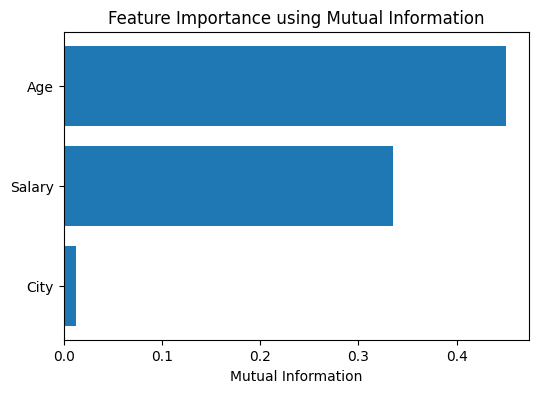

In [2]:
# Step 1: Import libraries
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Step 2: Load dataset
df = pd.read_csv("sample_data.csv")
print("Dataset:\n", df)

# Step 3: Encode categorical features (City and Purchased)
le_city = LabelEncoder()
df['City'] = le_city.fit_transform(df['City'])

le_target = LabelEncoder()
df['Purchased'] = le_target.fit_transform(df['Purchased'])  # No=0, Yes=1

# Step 4: Separate features and target
X = df.drop('Purchased', axis=1)
y = df['Purchased']

# Step 5: Compute Mutual Information
mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)

# Step 6: Display MI scores
mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)
print("\nMutual Information Scores:\n", mi_df)

# Optional: Plot MI
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.barh(mi_df['Feature'], mi_df['Mutual Information'])
plt.xlabel("Mutual Information")
plt.title("Feature Importance using Mutual Information")
plt.gca().invert_yaxis()
plt.show()

2.) Wapper method---->RFE(Recursive feature elimination)

(Given a person’s Age, Salary, and City, predict if they will purchase the product.)

In [3]:
# Step 0: Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Step 1: Load dataset
df = pd.read_csv("sample_data.csv")

# Step 2: Encode categorical variables
le_city = LabelEncoder()
df['City'] = le_city.fit_transform(df['City'])

le_target = LabelEncoder()
df['Purchased'] = le_target.fit_transform(df['Purchased'])  # No=0, Yes=1

# Step 3: Separate features and target
X = df.drop('Purchased', axis=1)
y = df['Purchased']

# Step 4: Choose model (Random Forest here)
model = RandomForestClassifier(random_state=42)

# Step 5: Apply RFE (select top 2 features)
rfe = RFE(model, n_features_to_select=2)
rfe.fit(X, y)

# Step 6: Check which features were selected
selected_features = X.columns[rfe.support_]
print("Selected Features:", list(selected_features))

# Step 7: Feature ranking
ranking = pd.DataFrame({'Feature': X.columns, 'Rank': rfe.ranking_})
print(ranking.sort_values(by='Rank'))

Selected Features: ['Age', 'Salary']
  Feature  Rank
0     Age     1
1  Salary     1
2    City     2


Embedded Method

LASSO

(Given a person’s Age, Salary, and City, predict if they will purchase the product.)

In [4]:
# Step 0: Import libraries
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Load dataset
df = pd.read_csv("sample_data.csv")

# Step 2: Encode categorical variables
le_city = LabelEncoder()
df['City'] = le_city.fit_transform(df['City'])

le_target = LabelEncoder()
df['Purchased'] = le_target.fit_transform(df['Purchased'])  # No=0, Yes=1

# Step 3: Separate features and target
X = df.drop('Purchased', axis=1)
y = df['Purchased']

# Step 4: Scale features (important for LASSO)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train LASSO
lasso = Lasso(alpha=0.1)  # alpha = regularization strength
lasso.fit(X_scaled, y)

# Step 6: Check which features are selected
selected_features = X.columns[lasso.coef_ != 0]
print("Selected Features by LASSO:", list(selected_features))

# Step 7: Feature coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})
print(coef_df)

Selected Features by LASSO: ['Age']
  Feature  Coefficient
0     Age     0.326498
1  Salary     0.000000
2    City    -0.000000
